# Figure 3

This plot compares the TCUSCAN segmented scan versus vector-only baseline segmented scan

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "v", "<", ">", "s", "X"]

_SNS_PARAMS = {"markers":_MARKERS, "dashes":True, "markersize": 10}

In [60]:
from glob import glob
from os.path import join

tot_dataframe = pd.concat(map(pd.read_csv, glob(join('..', f"bench_results*_seg_scan_sc_128_*fp16_*.csv"))))
tot_dataframe["operator"] = tot_dataframe["operator"].map({ "vec_seg_scan_sc_128": "Vector-only", "seg_scan_sc_128": "MMV-RAM"})

tot_dataframe["benchname"] = tot_dataframe["benchname"].map({"circuit5M": "Circuit5M", "mc2depi": "Epidemiology", "mac_econ_fwd500": "Economics", "ASIC_680k": "ASIC_680k", "pdb1HYS": "Protein"})


In [61]:
tot_dataframe.head(10)

,benchname,operator,dtype,time_us
0,Circuit5M,Vector-only,fp16,2118600.37
0,Epidemiology,Vector-only,fp16,75554.85
0,Economics,Vector-only,fp16,45765.53
0,ASIC_680k,MMV-RAM,fp16,2183.93
0,Protein,MMV-RAM,fp16,2443.24
0,ASIC_680k,Vector-only,fp16,138688.19
0,Circuit5M,MMV-RAM,fp16,32090.11
0,Protein,Vector-only,fp16,155629.51
0,Epidemiology,MMV-RAM,fp16,1240.68
0,Economics,MMV-RAM,fp16,789.79


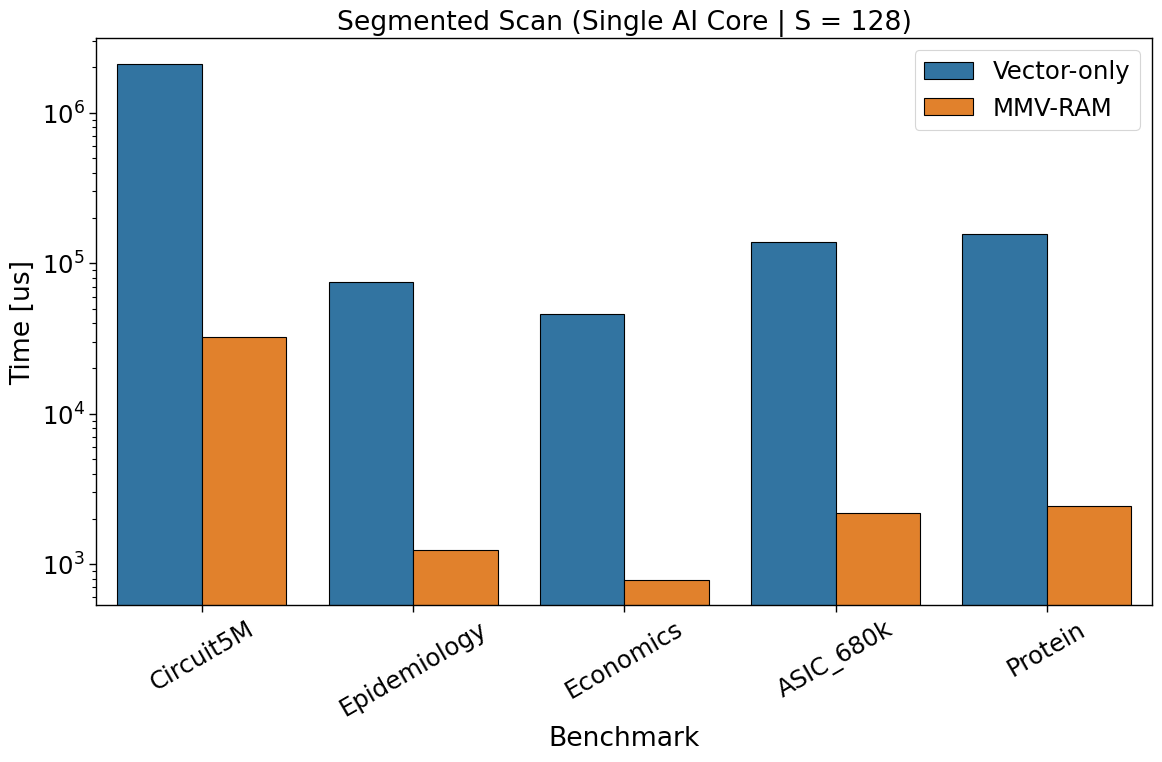

In [62]:
plt.figure(figsize=(12,8))

ax = sns.barplot(data=tot_dataframe, x="benchname", y="time_us", hue="operator", edgecolor="black")
plt.yscale("log")

plt.xlabel('Benchmark')
plt.xticks(rotation=30)
plt.ylabel('Time [us]')
plt.title('Segmented Scan (Single AI Core | S = 128)')
plt.legend(loc="upper right")
plt.tight_layout()

#plt.grid(True)

plt.savefig("sparsesuite_comparison_latency.png")
plt.savefig("sparsesuite_comparison_latency.pdf")
